# Data Understanding and Exploratory Data Analysis

**Notebook 01 — Phase 1**

## Executive Summary

Load and explore the IBM HR Analytics dataset. Assess quality, visualize distributions, correlations, and outliers with HR-focused interpretation.

## Objectives

- Load and inspect the raw dataset
- Assess data quality (missing, duplicates, constants)
- Perform visual and statistical EDA
- Extract business insights for retention strategy

## Expected Outputs

- Data quality summary
- EDA visualizations with interpretation
- Business insights table

## Required Inputs

- **Environment:** project root, virtualenv activated (`make install`)
- **Run from the **project root** with the virtual environment activated (`make install`).
- Prerequisites: Raw CSV at `data/raw/`; run `00_Project_Overview.ipynb` optional
- Reproducibility: `RANDOM_STATE = 42` where applicable.


## 1. Environment Setup

**Objective:** Import libraries and configure plotting.

**Methodology:** Use shared Phase 1 utilities from `notebooks/_shared/`.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "data" / "raw").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from notebooks._shared.config import (
    DATA_PATH, LIKERT_COLS, PROJECT_ROOT, RANDOM_STATE, TARGET,
)
from notebooks._shared.eda import iqr_outlier_summary
from notebooks._shared.plotting import attrition_rate_by, plot_distribution, setup_plot_style
from notebooks._shared.preprocessing import load_raw_dataset

np.random.seed(RANDOM_STATE)
setup_plot_style()
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path exists: {DATA_PATH.exists()}")

Project root: /mnt/d/Abhishek/Employee-Attrition Project
Data path exists: True


## 2. Load Dataset

**Objective:** Load raw data without transformations.

**Methodology:** Preserve raw data for transparent EDA; cleaning occurs in Notebook 02.

In [2]:
df = load_raw_dataset()
print(f"Shape: {df.shape}")
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Observations

Record row and column counts. Preview column names and sample values.

**Conclusion:** Dataset loaded successfully for exploration.

## 3. Dataset Overview

**Objective:** Summarize structure, dtypes, and cardinality.

In [3]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "unique": df.nunique(),
})
overview

Rows: 1,470 | Columns: 35


,dtype,non_null,unique
Age,int64,1470,43
Attrition,object,1470,2
BusinessTravel,object,1470,3
DailyRate,int64,1470,886
Department,object,1470,3
DistanceFromHome,int64,1470,29
Education,int64,1470,5
EducationField,object,1470,6
EmployeeCount,int64,1470,1
EmployeeNumber,int64,1470,1470


## 4. Data Quality Assessment

**Objective:** Identify missing values, duplicates, and non-informative columns.

**Methodology:** Check nulls, duplicate rows, constant columns, and identifier uniqueness.

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None")

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f"Constant columns: {constant_cols}")

if "EmployeeNumber" in df.columns:
    print(f"EmployeeNumber unique: {df['EmployeeNumber'].is_unique}")

Missing values per column:
None

Duplicate rows: 0
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
EmployeeNumber unique: True


### Observations

No missing values expected. Constants (`EmployeeCount`, `Over18`, `StandardHours`) and `EmployeeNumber` will be dropped in preprocessing.

**Business Interpretation:** Clean raw data reduces preprocessing risk; identifiers must not enter the model.

**Conclusion:** Data quality is suitable for modeling after column removal.

## 5. Statistical Summary

**Objective:** Describe numeric feature distributions.

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
stats = df[numeric_cols].describe().T
stats["skewness"] = df[numeric_cols].skew()
stats["kurtosis"] = df[numeric_cols].kurtosis()
print(f"Likert-scale columns: {LIKERT_COLS}")
stats.round(2)

Likert-scale columns: ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0,0.41,-0.40
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0,-0.00,-1.20
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0,0.96,-0.22
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0,-0.29,-0.56
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0,0.00,0.00
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0,0.02,-1.22
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0,-0.32,-1.20
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0,-0.03,-1.20
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0,-0.50,0.27
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0,1.03,0.40


## 6. Target Analysis

**Objective:** Quantify class imbalance.

**Methodology:** Count plot and attrition rate calculation.

/tmp/ipykernel_4295/4127693273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#2E86AB", "#E94F37"], ax=ax)


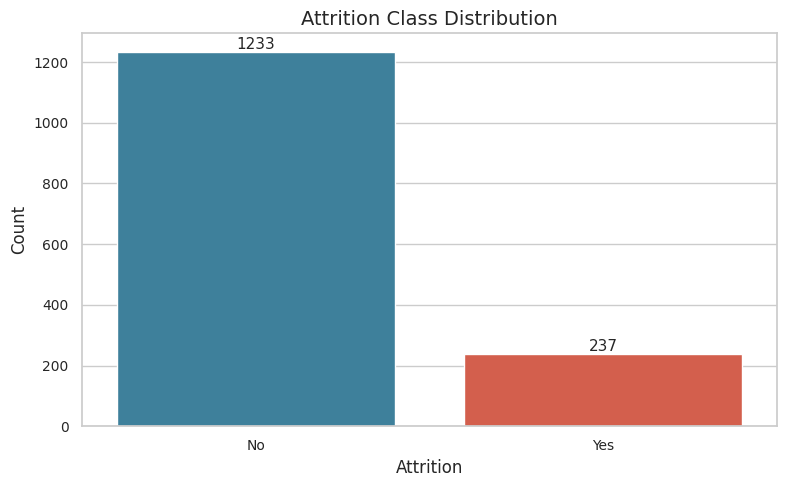

Attrition rate: 16.1%
Imbalance ratio (No:Yes): 5.2:1


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df[TARGET].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=["#2E86AB", "#E94F37"], ax=ax)
ax.set_title("Attrition Class Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.show()

attrition_pct = (df[TARGET] == "Yes").mean() * 100
imbalance = counts["No"] / counts["Yes"]
print(f"Attrition rate: {attrition_pct:.1f}%")
print(f"Imbalance ratio (No:Yes): {imbalance:.1f}:1")

**Objective:** Visualize class imbalance.

**Interpretation:** ~16% attrition creates a 5:1 imbalance.

**Business implication:** Models must handle imbalance; missing attriters (false negatives) is costly for HR.

## 7. Numerical Distributions

**Objective:** Compare key numeric features by attrition status.

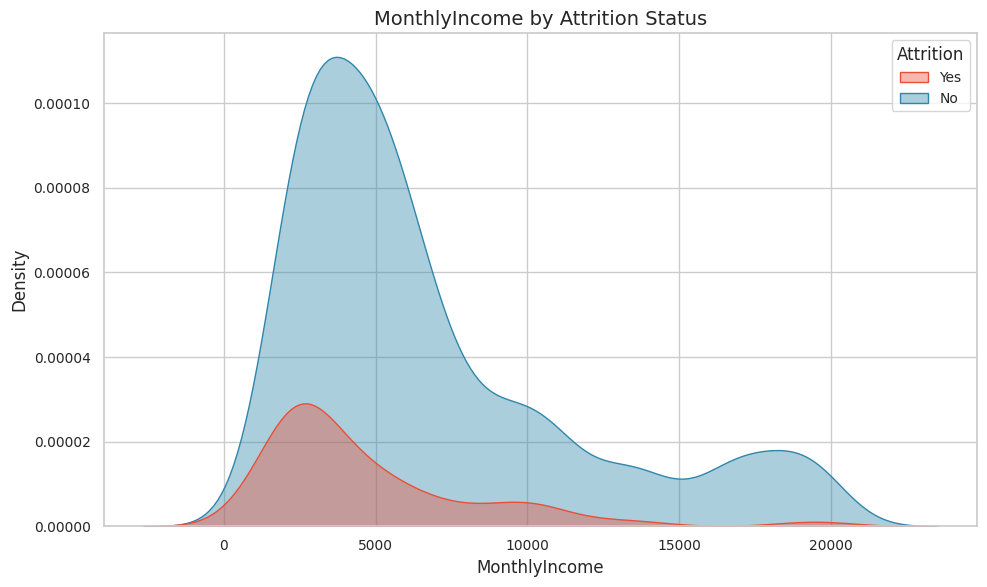

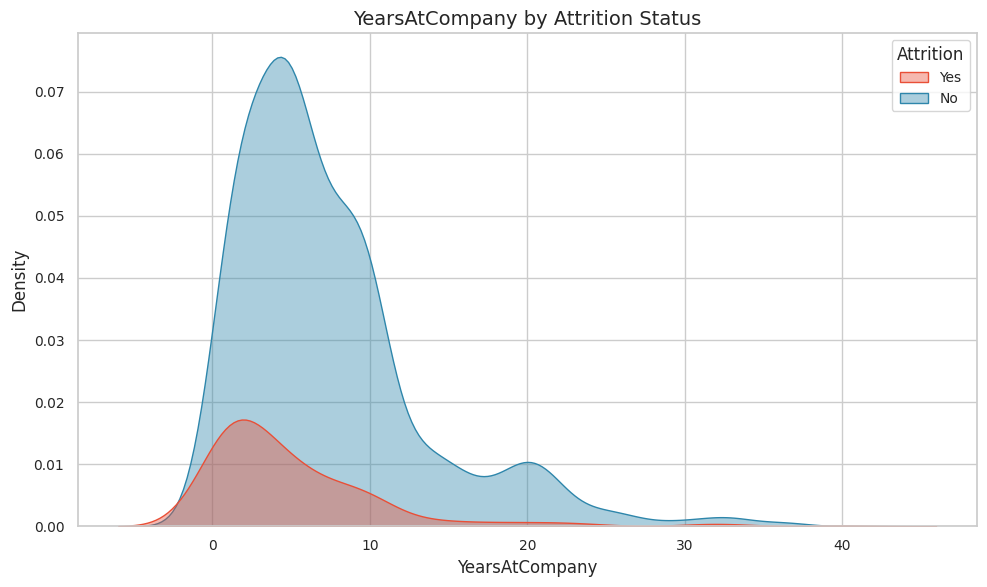

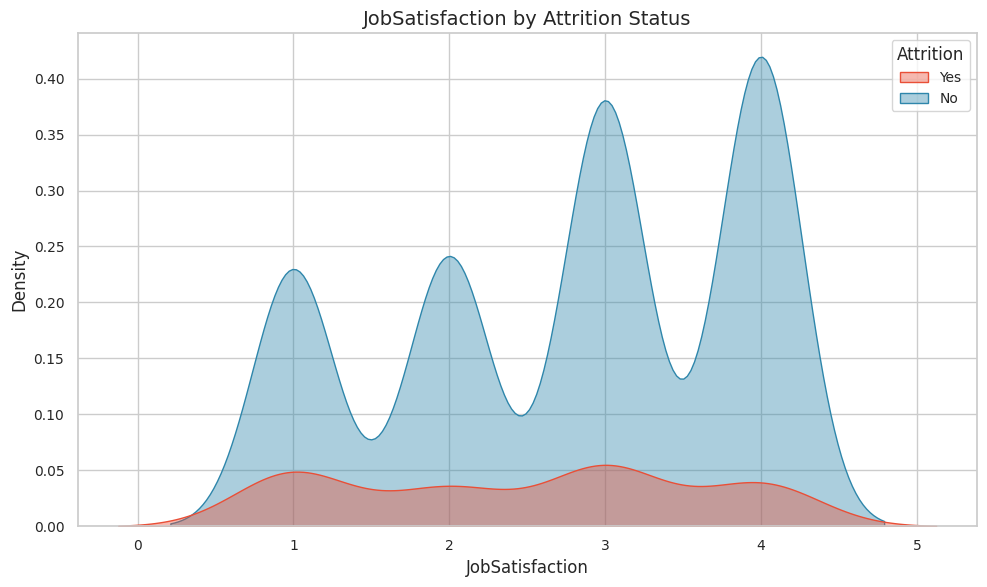

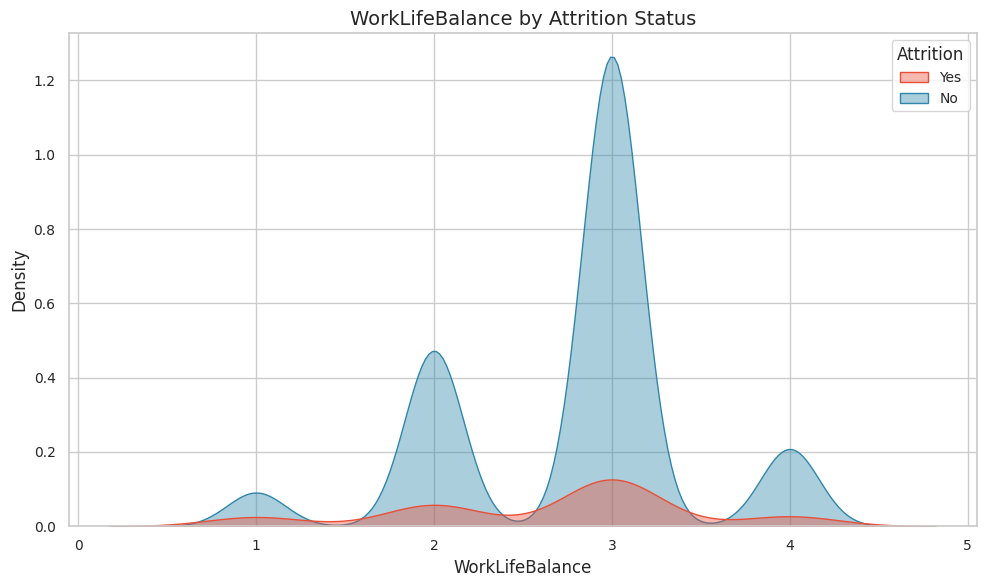

In [7]:
for col in ["MonthlyIncome", "YearsAtCompany", "JobSatisfaction", "WorkLifeBalance"]:
    plot_distribution(df, col, hue=TARGET, kind="kde")
    plt.show()

**Interpretation:** Leavers often show lower income, shorter tenure, and lower satisfaction scores.

**Business implication:** Compensation, tenure programs, and satisfaction initiatives are retention levers.

## 8. Correlation Analysis

**Objective:** Identify linear relationships with attrition.

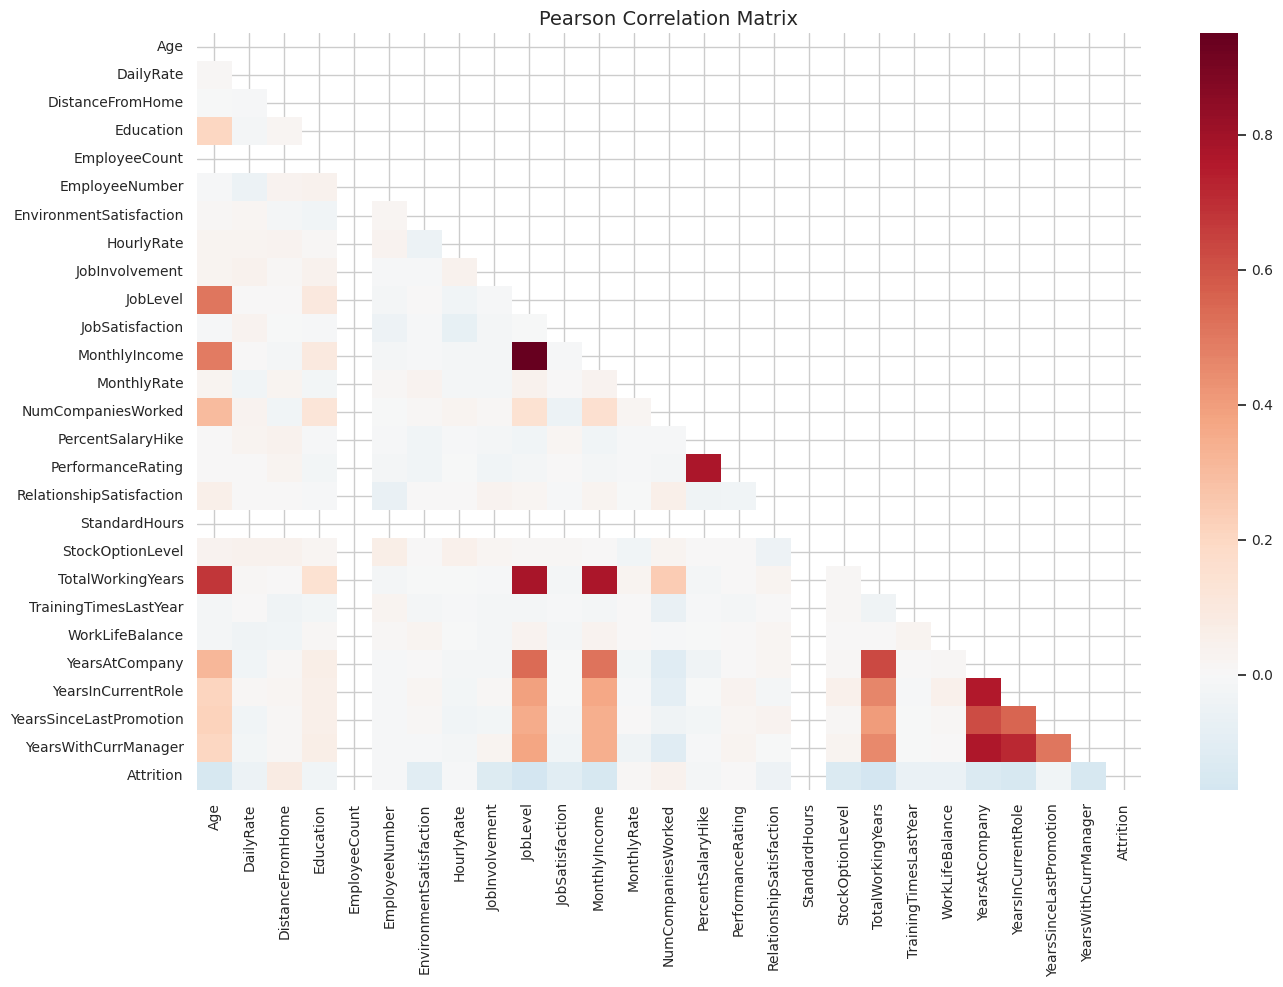

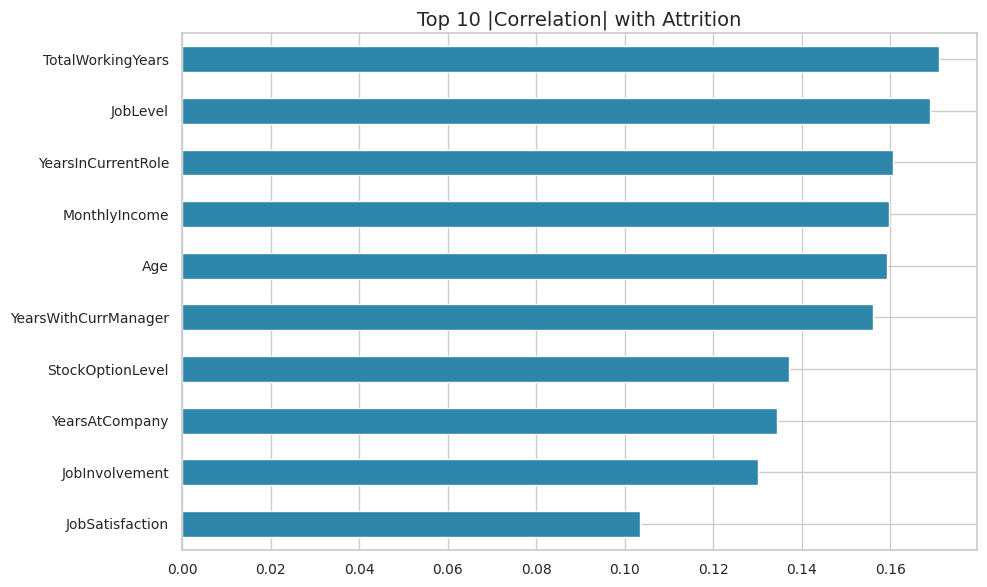

TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481
Name: Attrition, dtype: float64

In [8]:
corr = df[numeric_cols + [TARGET]].copy()
corr[TARGET] = (corr[TARGET] == "Yes").astype(int)
corr_matrix = corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0, ax=ax, annot=False)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
target_corr.head(10).sort_values().plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Top 10 |Correlation| with Attrition")
plt.tight_layout()
plt.show()
target_corr.head(10)

**Interpretation:** TotalWorkingYears, Age, and YearsAtCompany negatively correlate with attrition; StockOptionLevel and JobLevel are protective.

**Business implication:** Early-career and low-equity employees warrant proactive retention attention.

## 9. Outlier Analysis

**Objective:** Flag extreme values using IQR method.

In [9]:
outlier_df = iqr_outlier_summary(df, numeric_cols)
outlier_df.head(10)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
20,TrainingTimesLastYear,2.0,3.0,1.0,0.5,4.5,238,16.19
15,PerformanceRating,3.0,3.0,0.0,3.0,3.0,226,15.37
11,MonthlyIncome,2911.0,8379.0,5468.0,-5291.0,16581.0,114,7.76
24,YearsSinceLastPromotion,0.0,3.0,3.0,-4.5,7.5,107,7.28
22,YearsAtCompany,3.0,9.0,6.0,-6.0,18.0,104,7.07
18,StockOptionLevel,0.0,1.0,1.0,-1.5,2.5,85,5.78
19,TotalWorkingYears,6.0,15.0,9.0,-7.5,28.5,63,4.29
13,NumCompaniesWorked,1.0,4.0,3.0,-3.5,8.5,52,3.54
23,YearsInCurrentRole,2.0,7.0,5.0,-5.5,14.5,21,1.43
25,YearsWithCurrManager,2.0,7.0,5.0,-5.5,14.5,14,0.95


**Interpretation:** Outliers exist but are retained — extreme values may represent genuine high earners or long-tenure employees.

**Business implication:** Winsorization deferred; tree models in future phases handle outliers better.

## 10. Business Insights Dashboard

**Objective:** Summarize actionable HR insights from EDA.

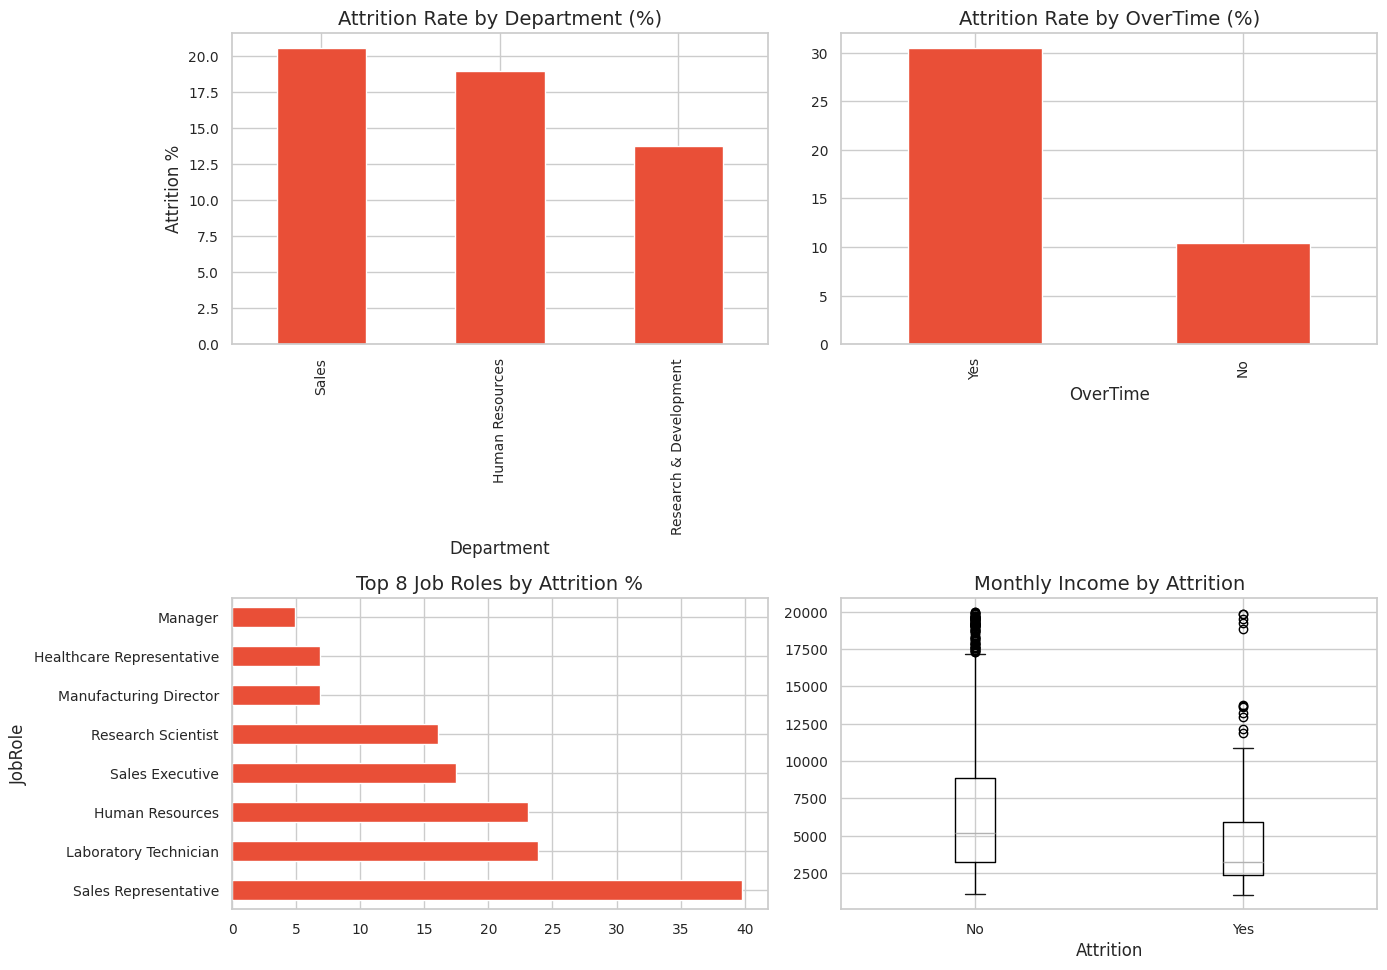

,Insight,Action
0,Sales dept highest attrition,Review sales comp and workload
1,Overtime strongly linked to attrition,Monitor overtime policies
2,Lower income among leavers,Benchmark compensation bands
3,Low satisfaction scores predict attrition,Pulse surveys and manager coaching


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

dept_rates = attrition_rate_by(df, "Department")
dept_rates.plot(kind="bar", ax=axes[0, 0], color="#E94F37")
axes[0, 0].set_title("Attrition Rate by Department (%)")
axes[0, 0].set_ylabel("Attrition %")

ot_rates = attrition_rate_by(df, "OverTime")
ot_rates.plot(kind="bar", ax=axes[0, 1], color="#E94F37")
axes[0, 1].set_title("Attrition Rate by OverTime (%)")

role_rates = attrition_rate_by(df, "JobRole").head(8)
role_rates.plot(kind="barh", ax=axes[1, 0], color="#E94F37")
axes[1, 0].set_title("Top 8 Job Roles by Attrition %")

df.boxplot(column="MonthlyIncome", by=TARGET, ax=axes[1, 1])
axes[1, 1].set_title("Monthly Income by Attrition")
plt.suptitle("")
plt.tight_layout()
plt.show()

eda_insights = pd.DataFrame([
    {"Insight": "Sales dept highest attrition", "Action": "Review sales comp and workload"},
    {"Insight": "Overtime strongly linked to attrition", "Action": "Monitor overtime policies"},
    {"Insight": "Lower income among leavers", "Action": "Benchmark compensation bands"},
    {"Insight": "Low satisfaction scores predict attrition", "Action": "Pulse surveys and manager coaching"},
])
eda_insights

## Future Connection

Notebook 02 applies leakage-safe preprocessing: drop identifiers, define feature roles, and create a stratified train/test split persisted to `data/interim/`.


## Conclusion

EDA reveals class imbalance, compensation/tenure/satisfaction drivers, and department-level risk patterns. Proceed to Notebook 02 for leakage-safe preprocessing.